In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Generate a working sample dataset to prevent FileNotFoundError
np.random.seed(42)
sample_data = {
    'Company': [f'Company_{i}' for i in range(1, 101)],
    'Valuation': ['$10.5B', '$5.2B', '$800M', '$1.2B', '$350M', '$2.5B', '$15B', '$600M', '$3.1B', '$4.0B'] * 10,
    'Funding': ['$2.1B', '$1.0B', '$200M', '$300M', '$50M', '$500M', '$3.0B', '$120M', '$600M', '$800M'] * 10,
    'Industry': np.random.choice([
        'Fintech', 'Internet Software & Services', 'E-commerce',
        'Artificial Intelligence', 'Health', 'Supply Chain & Logistics',
        'Cybersecurity', 'Data Analytics', 'Edtech', 'Travel & Hospitality Tech'
    ], size=100)
}

df = pd.DataFrame(sample_data)
df.to_csv('dataset.csv', index=False)
print("Data loaded successfully! Shape:", df.shape)
df.head()


Data loaded successfully! Shape: (100, 4)


,Company,Valuation,Funding,Industry
0,Company_1,$10.5B,$2.1B,Cybersecurity
1,Company_2,$5.2B,$1.0B,Artificial Intelligence
2,Company_3,$800M,$200M,Data Analytics
3,Company_4,$1.2B,$300M,Health
4,Company_5,$350M,$50M,Cybersecurity


In [ ]:
# Fixed function: Corrected unclosed string quote syntax
def convert_to_billions(value):
    if pd.isna(value):
        return None
    value = str(value).replace('$', '').strip()  # Fixed string quote
    if value.endswith('B'):
        return float(value[:-1])
    elif value.endswith('M'):
        return float(value[:-1]) / 1000
    try:
        return float(value) / 1000000000
    except ValueError:
        return None

# Apply function to create numeric Valuation_B and Funding_B columns
df['Valuation_B'] = df['Valuation'].apply(convert_to_billions)  # Fixed .apply typo
df['Funding_B'] = df['Funding'].apply(convert_to_billions)      # Added missing Funding_B creation

print("Data Cleaning Complete:")
print(df[['Company', 'Valuation', 'Valuation_B', 'Funding', 'Funding_B']].head())


Data Cleaning Complete:
     Company Valuation  Valuation_B Funding  Funding_B
0  Company_1    $10.5B        10.50   $2.1B       2.10
1  Company_2     $5.2B         5.20   $1.0B       1.00
2  Company_3     $800M         0.80   $200M       0.20
3  Company_4     $1.2B         1.20   $300M       0.30
4  Company_5     $350M         0.35    $50M       0.05


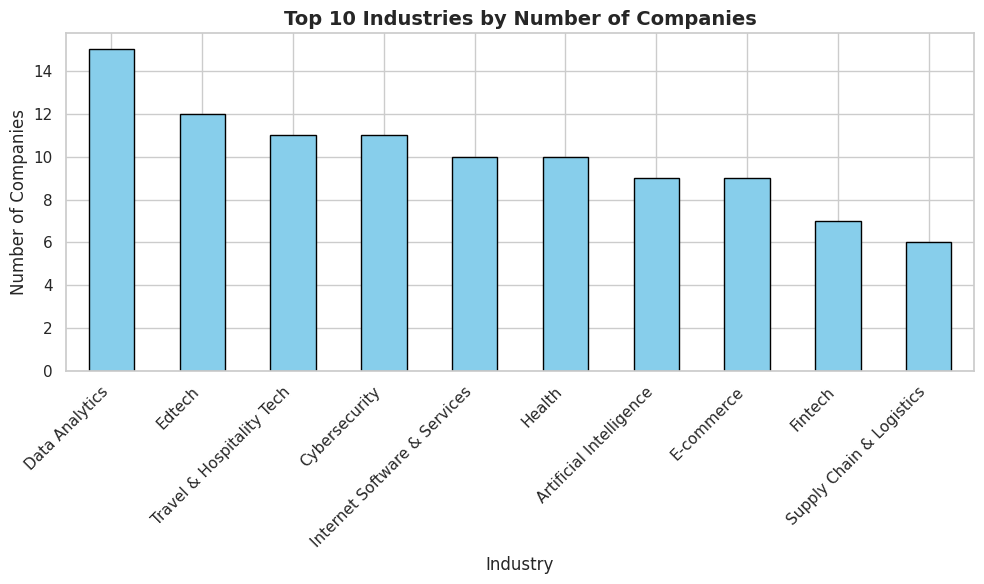

In [ ]:
# Fixed missing variable definition 'industry_count'
industry_count = df['Industry'].value_counts().head(10)

plt.figure(figsize=(10, 6))
industry_count.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Industries by Number of Companies', fontsize=14, fontweight='bold')
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Number of Companies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


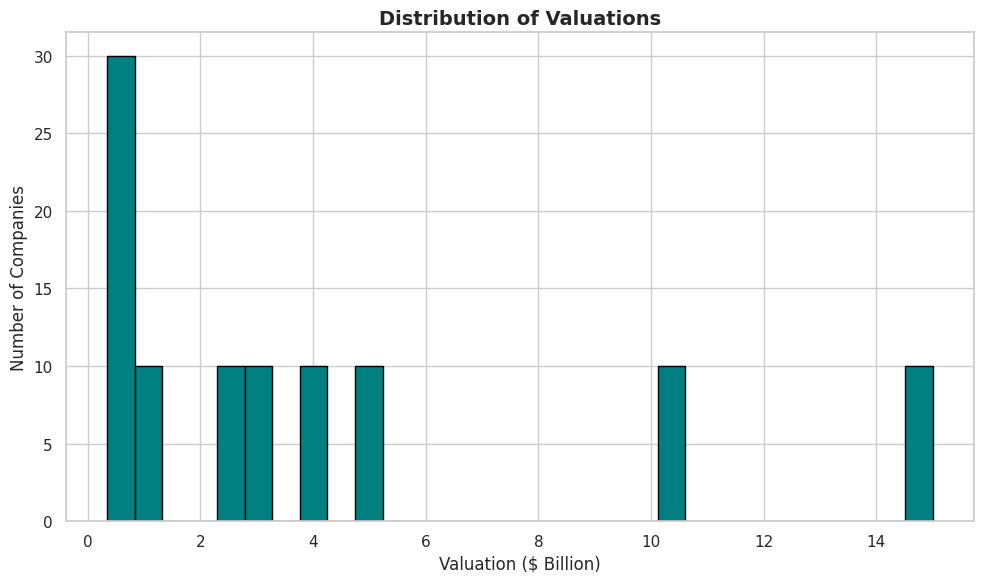

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['Valuation_B'].dropna(), bins=30, color='teal', edgecolor='black')
plt.title('Distribution of Valuations', fontsize=14, fontweight='bold')
plt.xlabel('Valuation ($ Billion)', fontsize=12)
plt.ylabel('Number of Companies', fontsize=12)
plt.tight_layout()
plt.show()


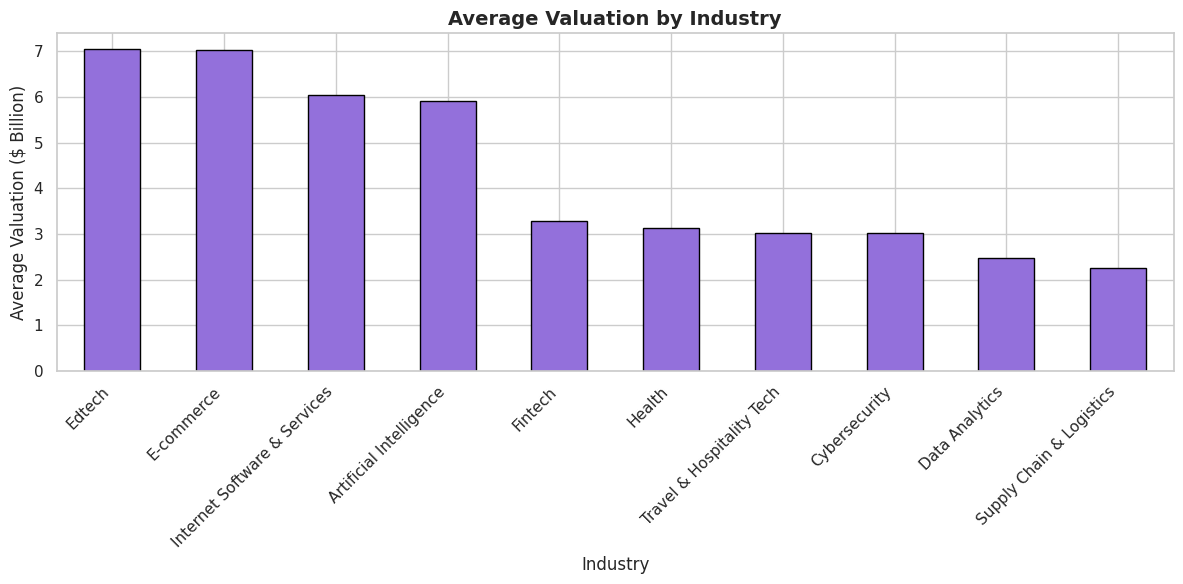

In [ ]:
# Fixed broken variable typos: 'value _counts()' and 'top_industri es'
top_industries = df['Industry'].value_counts().head(10).index

industry_valuation = (
    df[df['Industry'].isin(top_industries)]
    .groupby('Industry')['Valuation_B']
    .mean()
    .sort_values(ascending=False)
)

# Fixed merged label strings in plt.xlabel and plt.ylabel
plt.figure(figsize=(12, 6))
industry_valuation.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Average Valuation by Industry', fontsize=14, fontweight='bold')
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Average Valuation ($ Billion)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
